# Introduccción

En este notebook se presenta el desarrollo de un proyecto para predecir el precio de las viviendas en Medellín mediante diferentes modelos de aprendizaje de máquinas. Se presenta una comparación de diferentes modelos, entrenados en un dataset disponible en Kaggle, que recopila la información de varias viviendas en Colombia. Incluye información como número de habitaciones, número de baños, área total del inmueble y precio.

Para realizar este proyecto, se filtró la información solo de los inmuebles ubicados en Medellín 


Dataset principal: https://www.kaggle.com/datasets/julianusugaortiz/colombia-housing-properties-price

In [43]:
%matplotlib inline
# needed in jupyter notebook
import matplotlib.pyplot as plt

# Carga de datos

Se cargan los datos desde Kaggle directamente, usando la API de Kaggle

In [ ]:
# Instalando las dependencias necesarias
%pip install kagglehub scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Requires libomp: On Mac, you can install it running: brew install libomp
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [11]:
from pathlib import Path

import kagglehub
import pandas as pd

# Download latest version
dataset_path = Path(
    kagglehub.dataset_download("julianusugaortiz/colombia-housing-properties-price")
)

print("Path to dataset files:", dataset_path)

# Find and load the CSV file
csv_files = list(dataset_path.glob("*.csv"))
print("CSV files:", [file.name for file in csv_files])

csv_path = dataset_path / "co_properties.csv"
df = pd.read_csv(csv_path)

df.head()

Path to dataset files: /Users/kevin.parra/.cache/kagglehub/datasets/julianusugaortiz/colombia-housing-properties-price/versions/2
CSV files: ['co_properties.csv']


,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
0,KsjahK62rxcYKXXQjOdkqw==,Propiedad,2020-10-07,2021-10-09,2020-10-07,3.9210,-76.506000,Colombia,Valle del Cauca,NaN,...,7.0,NaN,NaN,1.300000e+09,COP,NaN,Casa Campestre en venta en darien 3469064,"HERMOSA CASA CAMPESTRE, &Aacute;REA 6,000 MT, ...",Casa,Venta
1,Y+gsBZYq1zu5NoR3V5oUGA==,Propiedad,2020-10-07,2021-01-06,2020-10-07,3.3577,-76.541811,Colombia,Valle del Cauca,Cali,...,7.0,NaN,NaN,2.800000e+09,COP,NaN,Casa en ciudsd jardin,Casa independiente con posiciona en ciudad jar...,Casa,Venta
2,Jpzqxj8/Vgf3Aa5ASxUBNg==,Propiedad,2020-10-07,2020-10-07,2020-10-07,3.3577,-76.541811,Colombia,Valle del Cauca,Cali,...,7.0,NaN,NaN,2.800000e+09,COP,Mensual,Casa en ciudsd jardin,Casa independiente con posiciona en ciudad jar...,Casa,Venta
3,ieuFnkFx/yHDD66iMV14Gw==,Propiedad,2020-10-07,2021-04-12,2020-10-07,3.3640,-76.538000,Colombia,Valle del Cauca,Cali,...,8.0,NaN,NaN,3.500000e+09,COP,NaN,Casa en venta en pance 1630426,"EXCELENTE CASA - LOTE 6,373 MT, EN OBRA GRIS U...",Casa,Venta
4,g4u5JM+hAHEk8SukRSjMzg==,Propiedad,2020-10-07,9999-12-31,2020-10-07,3.3910,-76.517000,Colombia,Valle del Cauca,Cali,...,9.0,NaN,NaN,4.800000e+08,COP,NaN,CASA EXTERNA BARRIO CIUDAD 2000,"CASA EXTERNA EN EL BARRIO CIUDAD 2000,CONSTRUI...",Casa,Venta


# Limpiando los datos

El dataset tiene varias propiedades que no son importantes para el problema, como la columna l1, que representa el país donde está ubicado el inmueble y para la cual todos los registros tienen el valor de "Colombia". Así mismo, ad_type, que tiene el mismo valor para todos los registros y no aporta ningún valor a los modelos.

Por lo tanto, se van a eliminar esas columnas

In [13]:
columns_to_keep = [
    "lat",
    "lon",
    "l3",
    "l4",
    "l5",
    "l6",
    "rooms",
    "bedrooms",
    "bathrooms",
    "surface_total",
    "surface_covered",
    "price",
    "title",
    "property_type",
    "operation_type",
]

discarded_columns = [col for col in df.columns if col not in columns_to_keep]

df_selected = df[columns_to_keep].copy()

print("Discarded columns:")
print(discarded_columns)

df_selected.head()

Discarded columns:
['id', 'ad_type', 'start_date', 'end_date', 'created_on', 'l1', 'l2', 'currency', 'price_period', 'description']


,lat,lon,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
0,3.9210,-76.506000,NaN,NaN,NaN,NaN,NaN,6.0,7.0,NaN,NaN,1.300000e+09,Casa Campestre en venta en darien 3469064,Casa,Venta
1,3.3577,-76.541811,Cali,Ciudad Jardín,NaN,NaN,NaN,NaN,7.0,NaN,NaN,2.800000e+09,Casa en ciudsd jardin,Casa,Venta
2,3.3577,-76.541811,Cali,Ciudad Jardín,NaN,NaN,NaN,NaN,7.0,NaN,NaN,2.800000e+09,Casa en ciudsd jardin,Casa,Venta
3,3.3640,-76.538000,Cali,Ciudad Jardín,NaN,NaN,NaN,5.0,8.0,NaN,NaN,3.500000e+09,Casa en venta en pance 1630426,Casa,Venta
4,3.3910,-76.517000,Cali,NaN,NaN,NaN,NaN,8.0,9.0,NaN,NaN,4.800000e+08,CASA EXTERNA BARRIO CIUDAD 2000,Casa,Venta


A continuación se presenta el significado de algunas demás columnas:

l1: Country

l2: Department

l3: City

l4: Zone

l5: Locality

l6: Neighborhood

Vamos a explorar los valores de estas columnas y ver si nos pueden aportar algo o por el contrario las podemos eliminar, recordando que se utilizarán solo los datos de inmuebles en Medellín

In [14]:
for col in ["l3", "l4", "l5", "l6"]:
    print(f"\nUnique values in {col}:")
    print(df_selected[col].dropna().unique())
    print(f"Total unique values: {df_selected[col].nunique(dropna=True)}")


Unique values in l3:
<StringArray>
[                'Cali',                 'Chía',                'Dagua',
              'Pereira',              'Jamundí',             'Restrepo',
            'Manizales',             'Medellín',           'Bogotá D.C',
          'Santa Marta',
 ...
              'Quipile', 'El Carmen de Bolívar',              'Caqueza',
           'Caicedonia',              'Fúquene',              'Buesaco',
              'Yaguará',          'Nuevo Colón',               'Sotara',
                'Ataco']
Length: 343, dtype: str
Total unique values: 343

Unique values in l4:
<StringArray>
[         'Ciudad Jardín',     'San Fernando Nuevo',               'Laureles',
     'Zona Noroccidental',        'Zona Occidental',         'Zona Chapinero',
                  'Caney',                   'Lili',        'Doce de Octubre',
             'La América',                  'Belén',             'El Poblado',
          'Villa Hermosa',             'Zona Norte',     'Zona Surocci

Sin duda estas columnas tienen bastantes valores unicos, representando diferentes barrios y localidades.

## Filtrando los datos de solo Medellín

Sin embargo, nuestro interés es filtrar solo la información de Medellín, vamos a filtrar el dataset para obtener solo los datos que nos interesena.

In [193]:
df_medellin = df_selected[df_selected["l3"] == "Medellín"].copy()

print("Medellín dataset shape:", df_medellin.shape)

df_medellin.head()

Medellín dataset shape: (262856, 15)


,lat,lon,l3,l4,l5,l6,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
46,NaN,NaN,Medellín,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,4.000000e+09,Casa en Venta Ubicado en MEDELLIN,Casa,Venta
47,6.238637,-75.602011,Medellín,Laureles,NaN,NaN,NaN,19.0,20.0,NaN,NaN,1.300000e+07,"CASA EN ARRIENDO, MEDELLIN-LAURELES",Casa,Arriendo
48,NaN,NaN,Medellín,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,1.500000e+07,Casa en Arriendo Ubicado en MEDELLIN,Casa,Arriendo
157,6.297802,-75.577835,Medellín,Doce de Octubre,NaN,NaN,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Venta de casa en Florencia,Casa,Venta
158,6.245972,-75.614730,Medellín,La América,NaN,NaN,7.0,7.0,NaN,NaN,NaN,2.500000e+06,Arriendo Casa Duplex en Santa Monica,Casa,Arriendo


In [179]:
for col in ["l4", "l5", "l6"]:
    print(f"\nUnique values in {col}:")
    print(df_medellin[col].unique())
    print(f"Total unique values: {df_medellin[col].nunique()}")


Unique values in l4:
<StringArray>
[                   nan,             'Laureles',      'Doce de Octubre',
           'La América',                'Belén',           'El Poblado',
        'Villa Hermosa',              'Robledo',             'Castilla',
           'San Javier',        'San Cristóbal',           'Santa Cruz',
          'Santa Elena',             'Guayabal',             'Aranjuez',
           'Candelaria',            'Altavista',             'Manrique',
         'Buenos Aires',              'Popular', 'San Antonio de Prado',
             'Palmitas']
Length: 22, dtype: str
Total unique values: 21

Unique values in l5:
<StringArray>
[nan]
Length: 1, dtype: str
Total unique values: 0

Unique values in l6:
<StringArray>
[nan]
Length: 1, dtype: str
Total unique values: 0


Vemos que para medellín, las columnas l5 y l6 no tienen ningún valor representativo, por tanto vamos a eliminarlas.

In [194]:
df_medellin = df_medellin.drop(columns=["l5", "l6"])

print("Medellín dataset shape after dropping l5 and l6:", df_medellin.shape)
print("Remaining columns:")
print(df_medellin.columns.tolist())

df_medellin.head()

Medellín dataset shape after dropping l5 and l6: (262856, 13)
Remaining columns:
['lat', 'lon', 'l3', 'l4', 'rooms', 'bedrooms', 'bathrooms', 'surface_total', 'surface_covered', 'price', 'title', 'property_type', 'operation_type']


,lat,lon,l3,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,title,property_type,operation_type
46,NaN,NaN,Medellín,NaN,NaN,NaN,8.0,NaN,NaN,4.000000e+09,Casa en Venta Ubicado en MEDELLIN,Casa,Venta
47,6.238637,-75.602011,Medellín,Laureles,NaN,19.0,20.0,NaN,NaN,1.300000e+07,"CASA EN ARRIENDO, MEDELLIN-LAURELES",Casa,Arriendo
48,NaN,NaN,Medellín,NaN,NaN,NaN,7.0,NaN,NaN,1.500000e+07,Casa en Arriendo Ubicado en MEDELLIN,Casa,Arriendo
157,6.297802,-75.577835,Medellín,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Venta de casa en Florencia,Casa,Venta
158,6.245972,-75.614730,Medellín,La América,7.0,7.0,NaN,NaN,NaN,2.500000e+06,Arriendo Casa Duplex en Santa Monica,Casa,Arriendo


In [181]:
print("Operation types")
print(df_medellin["operation_type"].dropna().unique())

Operation types
<StringArray>
['Venta', 'Arriendo', 'Arriendo temporal']
Length: 3, dtype: str


In [182]:
# Cantidad de registros por tipo de operación
print("\nRecords by operation type")
print(df_medellin["operation_type"].value_counts(dropna=False))


Records by operation type
operation_type
Arriendo             143439
Venta                119394
Arriendo temporal        23
Name: count, dtype: int64


In [183]:
print(df_medellin["property_type"].unique())

<StringArray>
[           'Casa',            'Lote',            'Otro',         'Oficina',
     'Apartamento', 'Local comercial',           'Finca',        'Depósito',
     'Parqueadero']
Length: 9, dtype: str


Así mismo, vemos que hay dos tipos de operaciones en el dataset: Venta y arriendo. En este proyecto nos enfocaremos solo en el precio de venta de un inmueble. Por tanto, vamos a filtrar solo por este tipo de operación

In [195]:
df_medellin = df_medellin[df_medellin["operation_type"] == "Venta"].copy()

df_medellin.drop(columns=["operation_type"], inplace=True)

Eliminamos adicionalmente otras columnas que se repiten y que no aportan mucho valor

In [244]:
df_medellin_clean = df_medellin.drop(columns=["l3", "title"]).copy()

<Axes: xlabel='lon', ylabel='lat'>

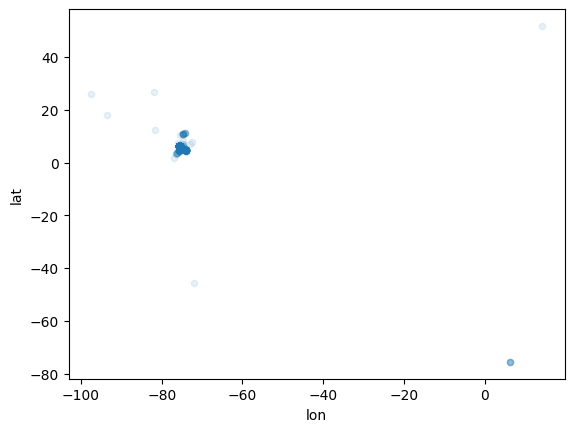

In [245]:
df_medellin_clean.plot(kind="scatter", x="lon", y="lat", alpha=0.1)

/var/folders/9r/f24wcwsd5lq1y7gwp439s8tm0000gn/T/ipykernel_55646/1320516810.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


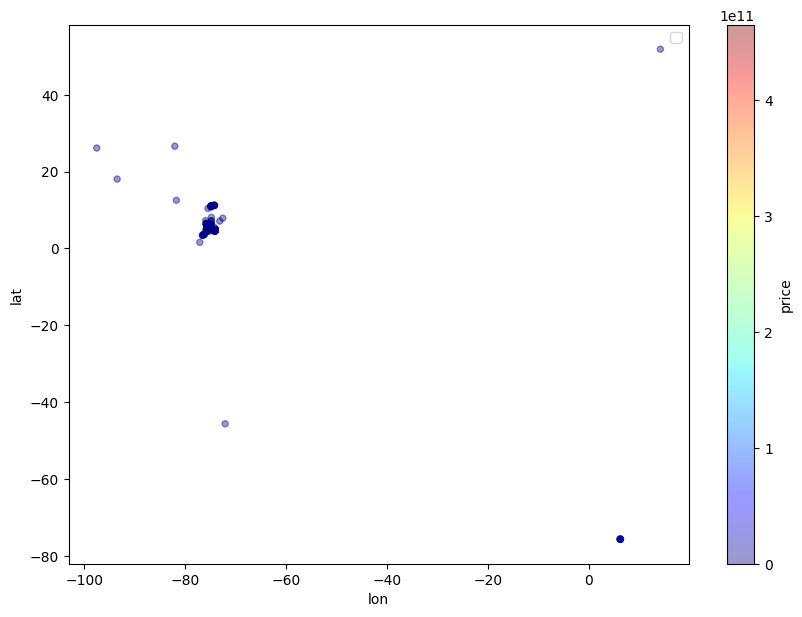

In [199]:
df_medellin_clean.plot(
    kind="scatter",
    x="lon",
    y="lat",
    alpha=0.4,
    figsize=(10, 7),
    c="price",
    cmap=plt.get_cmap("jet"),
    colorbar=True,
)
plt.legend()

In [246]:
df_medellin_clean.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,36540.000000,36540.000000,11889.000000,20456.000000,102697.000000,1356.000000,1442.000000,1.193700e+05
mean,6.214631,-75.561639,3.097906,2.995991,2.477677,498.648968,323.671290,5.644555e+08
std,1.130376,1.162069,1.300625,1.316010,1.290765,3172.582247,2902.863675,1.732681e+09
min,-75.580770,-97.494152,1.000000,0.000000,1.000000,11.000000,1.000000,0.000000e+00
25%,6.204034,-75.597782,3.000000,3.000000,2.000000,74.000000,74.000000,2.400000e+08
50%,6.228191,-75.577156,3.000000,3.000000,2.000000,120.000000,120.000000,3.450000e+08
75%,6.251000,-75.564960,3.000000,3.000000,3.000000,206.250000,200.000000,6.000000e+08
max,51.801231,14.154488,31.000000,41.000000,20.000000,83333.000000,105372.000000,4.650000e+11


In [247]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 119394 entries, 46 to 999044
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   lat              36540 non-null   float64
 1   lon              36540 non-null   float64
 2   l4               36417 non-null   str    
 3   rooms            11889 non-null   float64
 4   bedrooms         20456 non-null   float64
 5   bathrooms        102697 non-null  float64
 6   surface_total    1356 non-null    float64
 7   surface_covered  1442 non-null    float64
 8   price            119370 non-null  float64
 9   property_type    119394 non-null  str    
dtypes: float64(8), str(2)
memory usage: 14.1 MB


Mirando la información de las columnas, vemos que la mayoría tiene valores núlos para lat y lon y las demás variables.

In [248]:
df_medellin_clean = df_medellin_clean[df_medellin_clean["lat"].notna()].copy()
df_medellin_clean.head()

,lat,lon,l4,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
157,6.297802,-75.577835,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Casa
160,6.307000,-75.579002,Doce de Octubre,NaN,NaN,NaN,NaN,NaN,1.500000e+08,Casa
161,6.201145,-75.565205,El Poblado,3.0,3.0,NaN,NaN,NaN,1.250000e+09,Casa
162,6.256467,-75.557640,Villa Hermosa,6.0,6.0,NaN,NaN,NaN,1.800000e+08,Casa
345,6.259253,-75.628381,San Javier,NaN,NaN,1.0,NaN,NaN,3.800000e+07,Casa


Vemos que para ciertos features como surface_covered, lat, y lon, el valor no se tiene el valor disponible. Más adelante se tratatará ese caso, por ahora separemos los datos.

In [249]:
# Renombramos L4
df_medellin_clean.rename(columns={"l4": "neighborhood"}, inplace=True)

Por último, miremos si hay registros que no tengan el precio asignado

In [250]:
df_medellin_clean["price"][df_medellin["price"].isna()]

122402   NaN
176430   NaN
228065   NaN
228725   NaN
229994   NaN
240100   NaN
297577   NaN
299789   NaN
299979   NaN
304090   NaN
315120   NaN
333004   NaN
394965   NaN
502051   NaN
537055   NaN
772402   NaN
Name: price, dtype: float64

Son pocos registros, por lo tanto, eliminemoslos:

In [251]:
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"].notna()].copy()

In [252]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 36524 entries, 157 to 999044
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              36524 non-null  float64
 1   lon              36524 non-null  float64
 2   neighborhood     35936 non-null  str    
 3   rooms            11795 non-null  float64
 4   bedrooms         19199 non-null  float64
 5   bathrooms        24974 non-null  float64
 6   surface_total    1311 non-null   float64
 7   surface_covered  1392 non-null   float64
 8   price            36524 non-null  float64
 9   property_type    36524 non-null  str    
dtypes: float64(8), str(2)
memory usage: 3.1 MB


Guardamos el dataset con las modificaciones hechas y lo cargamos

In [253]:
from pathlib import Path

dataset_dir = Path("dataset")
dataset_dir.mkdir(exist_ok=True)

output_path = dataset_dir / "final_dataset.csv"
df_medellin_clean.to_csv(output_path, index=False)

print(f"Saved df_medellin to: {output_path}")

Saved df_medellin to: dataset/final_dataset.csv


In [2]:
import pandas as pd
df_medellin_clean = pd.read_csv("./dataset/final_dataset.csv")
df_medellin_clean.head()

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
0,6.297802,-75.577835,Doce de Octubre,5.0,5.0,NaN,NaN,NaN,3.100000e+08,Casa
1,6.307000,-75.579002,Doce de Octubre,NaN,NaN,NaN,NaN,NaN,1.500000e+08,Casa
2,6.201145,-75.565205,El Poblado,3.0,3.0,NaN,NaN,NaN,1.250000e+09,Casa
3,6.256467,-75.557640,Villa Hermosa,6.0,6.0,NaN,NaN,NaN,1.800000e+08,Casa
4,6.259253,-75.628381,San Javier,NaN,NaN,1.0,NaN,NaN,3.800000e+07,Casa


Buscando correlaciones

In [255]:
corr_matrix = df_medellin_clean.corr(numeric_only=True)
corr_matrix["price"].sort_values(ascending=False)

price              1.000000
bathrooms          0.565964
surface_total      0.238369
surface_covered    0.141749
rooms              0.057187
bedrooms           0.049842
lon                0.013530
lat               -0.015042
Name: price, dtype: float64

Vemos que las variables más correlacionadas son número de baños y area total

array([[<Axes: xlabel='price', ylabel='price'>,
        <Axes: xlabel='bathrooms', ylabel='price'>,
        <Axes: xlabel='surface_total', ylabel='price'>,
        <Axes: xlabel='rooms', ylabel='price'>],
       [<Axes: xlabel='price', ylabel='bathrooms'>,
        <Axes: xlabel='bathrooms', ylabel='bathrooms'>,
        <Axes: xlabel='surface_total', ylabel='bathrooms'>,
        <Axes: xlabel='rooms', ylabel='bathrooms'>],
       [<Axes: xlabel='price', ylabel='surface_total'>,
        <Axes: xlabel='bathrooms', ylabel='surface_total'>,
        <Axes: xlabel='surface_total', ylabel='surface_total'>,
        <Axes: xlabel='rooms', ylabel='surface_total'>],
       [<Axes: xlabel='price', ylabel='rooms'>,
        <Axes: xlabel='bathrooms', ylabel='rooms'>,
        <Axes: xlabel='surface_total', ylabel='rooms'>,
        <Axes: xlabel='rooms', ylabel='rooms'>]], dtype=object)

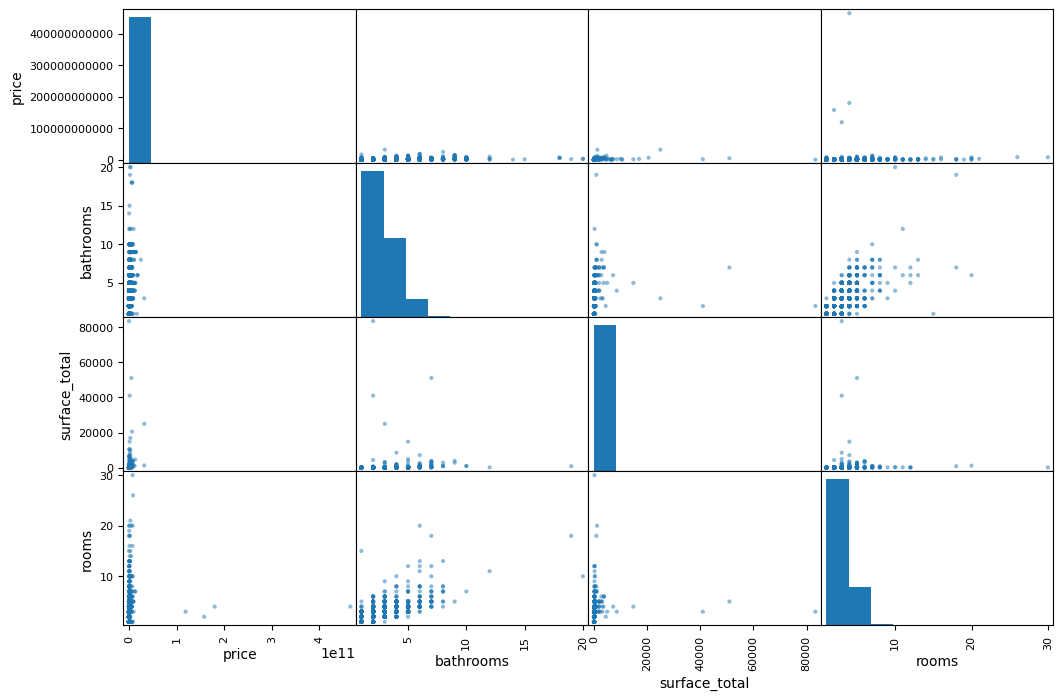

In [232]:
from pandas.plotting import scatter_matrix

attributes = [
    "price",
    "bathrooms",
    "surface_total",
    "rooms",
]
scatter_matrix(df_medellin_clean[attributes], figsize=(12, 8))

Veamos la gráfica de la variable más correlacionada por ahora:

<Axes: xlabel='bathrooms', ylabel='price'>

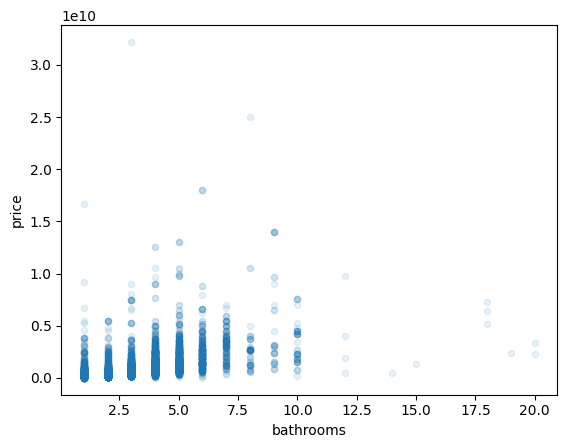

In [233]:
df_medellin_clean.plot(kind="scatter", x="bathrooms", y="price", alpha=0.1)

# Separando los datos de prueba y evaluación

In [3]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 36524 entries, 0 to 36523
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              36524 non-null  float64
 1   lon              36524 non-null  float64
 2   neighborhood     35936 non-null  str    
 3   rooms            11795 non-null  float64
 4   bedrooms         19199 non-null  float64
 5   bathrooms        24974 non-null  float64
 6   surface_total    1311 non-null   float64
 7   surface_covered  1392 non-null   float64
 8   price            36524 non-null  float64
 9   property_type    36524 non-null  str    
dtypes: float64(8), str(2)
memory usage: 2.8 MB


Vamos a manejar los outliers, en el precio, vemos que hay valores muy altos

In [5]:
q99 = df_medellin_clean["price"].quantile(0.99)
df_medellin_clean = df_medellin_clean[df_medellin_clean["price"] <= q99].copy()

In [5]:
df_medellin_clean.info()

<class 'pandas.DataFrame'>
Index: 36171 entries, 0 to 36523
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              36171 non-null  float64
 1   lon              36171 non-null  float64
 2   neighborhood     35591 non-null  str    
 3   rooms            11729 non-null  float64
 4   bedrooms         19074 non-null  float64
 5   bathrooms        24796 non-null  float64
 6   surface_total    1281 non-null   float64
 7   surface_covered  1364 non-null   float64
 8   price            36171 non-null  float64
 9   property_type    36171 non-null  str    
dtypes: float64(8), str(2)
memory usage: 3.0 MB


In [6]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df_medellin_clean, test_size=0.3, random_state=42)

In [7]:
train_set.head()

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,property_type
21269,6.262826,-75.542747,Manrique,NaN,NaN,NaN,NaN,NaN,41471422.0,Apartamento
23443,6.198628,-75.589530,Guayabal,NaN,NaN,2.0,NaN,NaN,195500000.0,Apartamento
7312,6.198252,-75.547199,Santa Elena,NaN,NaN,2.0,NaN,NaN,385000000.0,Apartamento
32531,6.246000,-75.603000,La América,NaN,2.0,2.0,NaN,NaN,295000000.0,Apartamento
15365,6.241270,-75.604498,Laureles,3.0,3.0,NaN,NaN,NaN,600000000.0,Casa


Separamos los datos de la variable objetivo, en este caso precio

In [277]:
train_set.info()

<class 'pandas.DataFrame'>
Index: 25319 entries, 32461 to 15943
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lat              25319 non-null  float64
 1   lon              25319 non-null  float64
 2   neighborhood     24917 non-null  str    
 3   rooms            8262 non-null   float64
 4   bedrooms         13348 non-null  float64
 5   bathrooms        17310 non-null  float64
 6   surface_total    878 non-null    float64
 7   surface_covered  930 non-null    float64
 8   price            25319 non-null  float64
 9   property_type    25319 non-null  str    
dtypes: float64(8), str(2)
memory usage: 2.1 MB


In [8]:
house_data = train_set.drop(columns=["price"])
target = train_set["price"]

Usamos SimpleImputer para llenar los valores NaN de las variables númericas, además se crea un pipeline que se puede reusar para el momento de la evaluación. Adicionalmente, hacemos estandarización en los datos para evitar problemas con outliers y tener los datos escalados para el modelo. Esto para las variables númericas:

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


house_num_features = house_data.drop(["neighborhood", "property_type"], axis=1)

num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("std_scaler", StandardScaler()),
    ]
)

Ahora procesamos las variables categoricas, en este caso tenemos property_type y neighborhood. Para ambas haremos OneHotEnconder ya que no son muchas las categorías disponibles

In [10]:
house_data["neighborhood"] = house_data["neighborhood"].fillna("Unknown")

In [11]:
house_data

,lat,lon,neighborhood,rooms,bedrooms,bathrooms,surface_total,surface_covered,property_type
21269,6.262826,-75.542747,Manrique,NaN,NaN,NaN,NaN,NaN,Apartamento
23443,6.198628,-75.589530,Guayabal,NaN,NaN,2.0,NaN,NaN,Apartamento
7312,6.198252,-75.547199,Santa Elena,NaN,NaN,2.0,NaN,NaN,Apartamento
32531,6.246000,-75.603000,La América,NaN,2.0,2.0,NaN,NaN,Apartamento
15365,6.241270,-75.604498,Laureles,3.0,3.0,NaN,NaN,NaN,Casa
...,...,...,...,...,...,...,...,...,...
17170,6.184278,-75.572689,El Poblado,NaN,NaN,3.0,NaN,NaN,Apartamento
6380,6.217403,-75.602807,Belén,3.0,3.0,NaN,NaN,NaN,Apartamento
11492,6.229415,-75.545502,Buenos Aires,NaN,NaN,3.0,NaN,NaN,Casa
876,6.231514,-75.591407,Belén,3.0,3.0,NaN,NaN,NaN,Apartamento


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

num_attribs = list(house_num_features)
cat_attribs = ["neighborhood", "property_type"]

full_pipeline = ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ]
)
housing_prepared = full_pipeline.fit_transform(house_data)

Una vez preparado el dataset de entrenamiento, podemos proceder a evaluar los modelos.

## Regresión Lineal

Empezaremos por uno de los modelos más sencillos que existimos y veremos que tal es su desempeño.

In [283]:
target[target.isna()]

Series([], Name: price, dtype: float64)

In [296]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, target) # train the model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Evaluación

In [297]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

predicted_price = lin_reg.predict(housing_prepared)


lm_mbe = mean_absolute_error(target, predicted_price)
lm_mse = mean_squared_error(target, predicted_price)
lm_rmse = np.sqrt(lm_mse)
lm_r2s = r2_score(target, predicted_price)

print("MAE:", lm_mbe)
print("MSE:", lm_mse)
print("RMSE:", lm_rmse)
print("R2_score:", lm_r2s)

MAE: 240541580.27670768
MSE: 1.6218217713952342e+17
RMSE: 402718483.7321518
R2_score: 0.4706594938835704


## Arbol de decisión

Probemos ahora con la regresión usando arbol de decisión

In [287]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, target)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [298]:
predicted_price = tree_reg.predict(housing_prepared)

tree_mbe = mean_absolute_error(target, predicted_price)
tree_mse = mean_squared_error(target, predicted_price)
tree_rmse = np.sqrt(tree_mse)
tree_r2s = r2_score(target, predicted_price)

print("MAE:", tree_mbe)
print("MSE:", tree_mse)
print("RMSE:", tree_rmse)
print("R2_score:", tree_r2s)

MAE: 27427051.966017157
MSE: 1.1163618632711734e+16
RMSE: 105658026.82575391
R2_score: 0.9635634713915162


Nos da un r2_score en entrenamiento de 0.96, bastante bueno pero podría haber overfiting. Usemos cross validation para correr varias veces el modelo y ver el error cuadratico medio:

In [299]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, housing_prepared, target,
                             scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [290]:
def display_scores(scores):
  print("Scores:", scores)
  print("Mean:", scores.mean())
  print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [3.68260008e+08 3.79937456e+08 3.72818350e+08 3.60639904e+08
 3.54335348e+08 3.54114182e+08 3.81534707e+08 3.69341779e+08
 4.15187546e+08 3.36877868e+08]
Mean: 369304715.0054081
Standard deviation: 19906567.041852213


Se observa todavía un error bastante alto, de 360+ millones, y los resultados varían aprox 20M, lo que indica que el modelo es estable, pero de todas formas el error es alto.

## Random Forest


In [18]:
from sklearn.ensemble import RandomForestRegressor 

# Training
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [19]:
predicted_price = forest_reg.predict(housing_prepared)

random_forest_mbe = mean_absolute_error(target, predicted_price)
random_forest_mse = mean_squared_error(target, predicted_price)
random_forest_rmse = np.sqrt(random_forest_mse)
random_forest_r2s = r2_score(target, predicted_price)

print("MAE:", random_forest_mbe)
print("MSE:", random_forest_mse)
print("RMSE:", random_forest_rmse)
print("R2_score:", random_forest_r2s)

MAE: 62451138.00347564
MSE: 1.5733119421488294e+16
RMSE: 125431732.11547504
R2_score: 0.9293848989944613


### Usando cross validation

In [303]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(forest_reg, housing_prepared, target,
                             scoring="neg_mean_squared_error", cv=10)
random_forest_rmse_scores = np.sqrt(-scores)

In [304]:
display_scores(random_forest_rmse_scores)

Scores: [2.85568829e+08 2.95782486e+08 3.24135845e+08 3.05405892e+08
 2.97677067e+08 2.81093111e+08 3.17187807e+08 3.18986882e+08
 3.42007030e+08 2.92494532e+08]
Mean: 306033947.91865045
Standard deviation: 18202843.105892885


Vemos un error típico de 306M con una variación de 18M aprox. Un poco mejor que con el arbol de decisión. Tendremos que optimizar los parametros para encontrar el mejor modelo.

## XGBoost

In [20]:
from xgboost import XGBRegressor

r_xgboost = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
r_xgboost.fit(housing_prepared, target)
r_xgboost.n_estimators

100

In [21]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

predicted_price = r_xgboost.predict(housing_prepared)

xgboost_mbe = mean_absolute_error(target, predicted_price)
xgboost_mse = mean_squared_error(target, predicted_price)
xgboost_rmse = np.sqrt(xgboost_mse)
xgboost_r2s = r2_score(target, predicted_price)

print("MAE:", xgboost_mbe)
print("MSE:", xgboost_mse)
print("RMSE:", xgboost_rmse)
print("R2_score:", xgboost_r2s)

MAE: 186441155.79965705
MSE: 9.50838218174901e+16
RMSE: 308356647.1109227
R2_score: 0.5732344297555994


## Redes neuronales

In [22]:
from sklearn.neural_network import MLPRegressor

r_red_neuronal = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
r_red_neuronal.fit(housing_prepared, target)
r_red_neuronal.n_layers_

/opt/anaconda3/envs/ml_tf/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


4

In [23]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

predicted_price = r_red_neuronal.predict(housing_prepared)

red_neuronal_mbe = mean_absolute_error(target, predicted_price)
red_neuronal_mse = mean_squared_error(target, predicted_price)
red_neuronal_rmse = np.sqrt(red_neuronal_mse)
red_neuronal_r2s = r2_score(target, predicted_price)

print("MAE:", red_neuronal_mbe)
print("MSE:", red_neuronal_mse)
print("RMSE:", red_neuronal_rmse)
print("R2_score:", red_neuronal_r2s)

MAE: 212536636.17175755
MSE: 1.1750987895137878e+17
RMSE: 342797139.6487707
R2_score: 0.47257935638835447


Aunque XGBoost son modelos más avanzados, sus paramatros no están optimizados por lo tanto su r2 fue bajo.